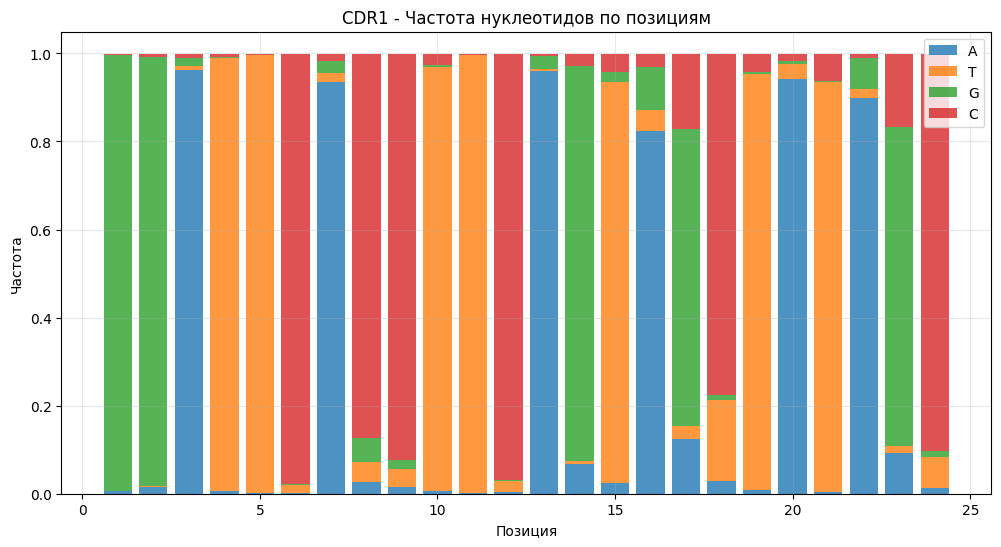

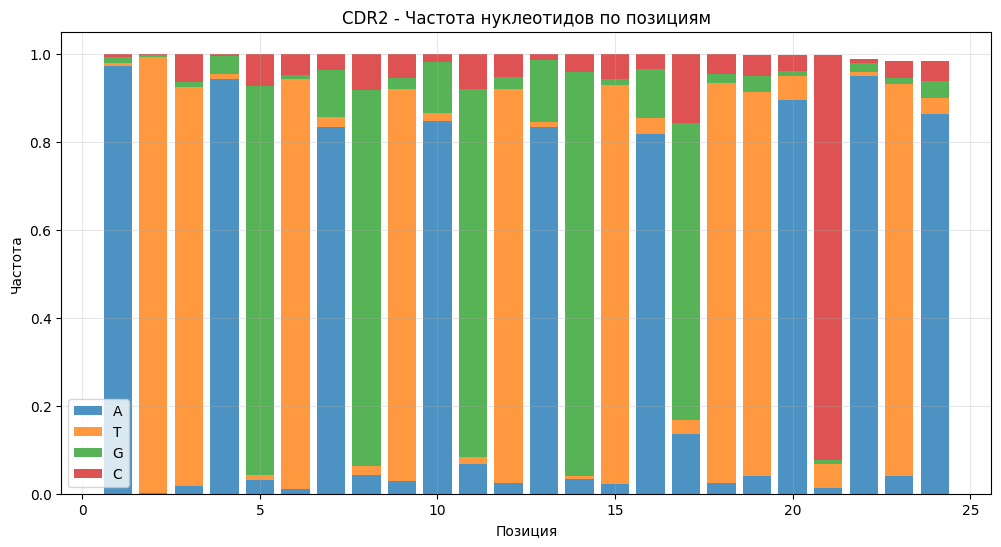

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загружаем данные
df = pd.read_csv("/Users/veronikaaksinina/Downloads/all_ighv3-21_cdr_data.csv")

# Берем столбцы
cdr1 = df.iloc[:, 0]  # CDR1
cdr2 = df.iloc[:, 2]  # CDR2

# Функция для анализа частот
def plot_nucleotide_freq(sequences, title):
    seq_len = len(sequences.iloc[0])
    nucleotides = ['A', 'T', 'G', 'C']
    
    # Считаем частоты
    freq_data = []
    for pos in range(seq_len):
        pos_bases = sequences.str[pos]
        counts = [pos_bases.str.count(nt).sum() for nt in nucleotides]
        total = len(sequences)
        freqs = [c/total for c in counts]
        freq_data.append(freqs)
    
    # Рисуем график
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = range(1, seq_len + 1)
    bottom = np.zeros(seq_len)
    
    for i, nt in enumerate(nucleotides):
        values = [freq_data[pos][i] for pos in range(seq_len)]
        ax.bar(x, values, bottom=bottom, label=nt, alpha=0.8)
        bottom = [bottom[j] + values[j] for j in range(seq_len)]
    
    ax.set_xlabel('Позиция')
    ax.set_ylabel('Частота')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()

# Анализируем CDR1 и CDR2
plot_nucleotide_freq(cdr1, "CDR1 - Частота нуклеотидов по позициям")
plot_nucleotide_freq(cdr2, "CDR2 - Частота нуклеотидов по позициям")